In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv('/content/lasso_batchy.csv')
data = data.drop(columns=['Unnamed: 0'])
data.head()

,Gene,C1,C2,C3,C4,C5,C6,C7,C8,C9,...,D29,D30,D31,D32,D33,D34,D35,D36,D37,D38
0,ACSM1,10.914760,11.135962,8.891566,8.074361,9.557551,10.132283,10.019072,8.925043,11.817970,...,7.659350,6.397556,6.226404,5.630004,7.850567,6.779979,5.882256,10.540738,7.262209,7.532407
1,ADORA2B,5.110096,5.805840,4.750283,5.620902,5.434974,5.514895,4.450006,6.229374,4.439311,...,6.540154,5.116456,5.080135,7.398721,6.450155,3.579958,5.938070,6.692122,6.385460,5.950856
2,AGPAT1,3.896571,5.078981,4.389263,5.705530,5.356997,5.326282,5.437688,4.551041,2.857657,...,5.213546,5.277771,6.954467,7.280251,6.796259,8.176044,6.867025,6.206010,7.782533,6.400674
3,BTBD16,6.838794,6.487988,6.991046,5.690952,6.632153,6.535228,6.927929,4.979223,7.734810,...,4.949167,4.854093,2.889749,5.578432,5.914876,6.037106,4.780228,3.544489,3.142159,4.833111
4,CCDC178,6.137514,6.115845,5.544265,6.502288,8.371001,6.477630,8.866079,5.789687,5.656918,...,4.466889,4.313042,3.611286,4.570975,5.151161,3.790559,4.200692,4.406053,4.664216,4.987756


In [ ]:
data = data.T

In [ ]:
y = data.index.to_series().str[0]
y = y.map({'C': 0, 'D': 1})
y = y.drop("Gene")
y
data.reset_index(inplace = True)

data.drop("index", axis = 1, inplace = True)
X = data
# Make first row the header
X.columns = X.iloc[0]

# Remove that first row
X = X.drop(X.index[0])

# Convert to numeric
X = X.apply(pd.to_numeric)
X


,ACSM1,ADORA2B,AGPAT1,BTBD16,CCDC178,CD207,CLRN1,CMA1,CSMD1,DDT,...,SFRP4,SIK1,SLC2A14,SORCS3,STC1,TBC1D3L,TNFRSF17,TYR,USP17L2,WDR46
1,10.914760,5.110096,3.896571,6.838794,6.137514,6.335811,6.009826,4.404689,8.698855,3.646425,...,12.193521,5.697186,2.974660,5.043856,6.742106,4.391362,5.723762,7.119836,8.620417,4.919325
2,11.135962,5.805840,5.078981,6.487988,6.115845,4.977656,5.474359,5.221860,7.239703,3.538015,...,10.480460,5.022233,4.247290,4.857951,4.822149,4.373500,6.082677,6.200747,8.470901,4.877400
3,8.891566,4.750283,4.389263,6.991046,5.544265,5.854893,6.827014,5.897843,10.042353,4.492789,...,11.926017,4.880500,3.793164,3.881190,7.631016,4.571990,5.470134,5.550446,8.192874,3.748831
4,8.074361,5.620902,5.705530,5.690952,6.502288,5.733583,4.652300,5.626731,8.580342,3.771152,...,13.494115,6.238118,2.781264,5.574711,8.175455,4.230194,6.473276,5.648787,7.811523,3.628753
5,9.557551,5.434974,5.356997,6.632153,8.371001,6.031605,5.919477,4.324369,7.790120,3.969257,...,11.788102,6.211392,3.135282,3.558551,6.543452,4.989646,6.105548,6.003599,7.399032,4.015435
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,6.779979,3.579958,8.176044,6.037106,3.790559,5.955599,8.112708,3.799325,6.478235,3.457107,...,10.890283,6.371103,5.944549,7.714985,9.056544,2.989828,5.051926,4.590912,7.227312,7.534752
68,5.882256,5.938070,6.867025,4.780228,4.200692,7.120193,7.008641,5.275480,6.822246,3.674302,...,11.551356,4.638456,5.725493,7.030303,9.135109,4.425790,4.721240,4.575075,6.103253,6.043637
69,10.540738,6.692122,6.206010,3.544489,4.406053,8.428116,6.119198,3.879046,8.752773,3.514716,...,9.344778,6.806512,4.146754,4.050462,10.532865,5.542763,4.414228,4.553074,5.016077,5.212523
70,7.262209,6.385460,7.782533,3.142159,4.664216,6.850532,4.242906,4.150065,6.151992,5.022798,...,10.195798,9.094513,3.853907,4.198532,11.917931,5.721694,5.591699,2.992995,2.595225,4.808556


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import json
import numpy as np
import pandas as pd
import os

# ── Output directory ──────────────────────────────────────────────
save_dir = "/content/drive/MyDrive/RF/10_10"
os.makedirs(save_dir, exist_ok=True)

# ── Define base model ─────────────────────────────────────────────
model = RandomForestClassifier(random_state=42)

# ── Hyperparameter grid ───────────────────────────────────────────
param_grid = {
    'n_estimators':      [100, 200, 300,400,500],
    'max_depth':         [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features':      ['sqrt', 'log2']
}

# ── Repeated Stratified K-Fold ────────────────────────────────────
rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=42)

# ── Grid Search ───────────────────────────────────────────────────
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=rskf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X, y)

# ── Extract results ───────────────────────────────────────────────
best_index  = grid_search.best_index_
cv_results  = grid_search.cv_results_
train_score = cv_results['mean_train_score'][best_index]
test_score  = cv_results['mean_test_score'][best_index]
std_score   = cv_results['std_test_score'][best_index]
best_model  = grid_search.best_estimator_

# ── Console output ────────────────────────────────────────────────
print("=" * 50)
print(f"Best Parameters     : {grid_search.best_params_}")
print(f"Best CV Accuracy    : {grid_search.best_score_*100:.2f}%")
print("=" * 50)
print(f"Mean Train Accuracy : {train_score*100:.2f}%")
print(f"Mean CV Accuracy    : {test_score*100:.2f}%")
print(f"Std Deviation       : {std_score*100:.2f}%")

# ── Predictions ───────────────────────────────────────────────────
y_pred = best_model.predict(X)
print("\nClassification Report:")
print(classification_report(y, y_pred))

# ── Build master DataFrame ────────────────────────────────────────
cv_df = pd.DataFrame(cv_results)
cv_df['mean_train_score'] *= 100
cv_df['std_train_score']  *= 100
cv_df['mean_test_score']  *= 100
cv_df['std_test_score']   *= 100

# ── 1. Save best model (.pkl) ─────────────────────────────────────
model_path = os.path.join(save_dir, "rf_best_model.pkl")
joblib.dump(best_model, model_path)
print(f"\n[Saved] Model              → {model_path}")

# ── 2. Save best params + scores (.json) ─────────────────────────
results_dict = {
    "best_params":         grid_search.best_params_,
    "best_cv_accuracy":    round(grid_search.best_score_ * 100, 4),
    "mean_train_accuracy": round(train_score * 100, 4),
    "mean_cv_accuracy":    round(test_score * 100, 4),
    "std_deviation":       round(std_score * 100, 4)
}
json_path = os.path.join(save_dir, "best_params_scores.json")
with open(json_path, "w") as f:
    json.dump(results_dict, f, indent=4)
print(f"[Saved] Params+Scores      → {json_path}")

# ── 3. Save full cv_results grid (.json) ──────────────────────────
cv_results_serializable = {
    k: v.tolist() if isinstance(v, np.ndarray) else list(v)
    for k, v in cv_results.items()
}
cv_json_path = os.path.join(save_dir, "cv_results_grid.json")
with open(cv_json_path, "w") as f:
    json.dump(cv_results_serializable, f, indent=4)
print(f"[Saved] CV Grid JSON       → {cv_json_path}")

# ── 3b. Save full cv_results (.csv) ──────────────────────────────
full_csv_path = os.path.join(save_dir, "cv_results_full.csv")
cv_df.to_csv(full_csv_path, index=False)
print(f"[Saved] CV Grid CSV        → {full_csv_path}")

# ── 3c. Per-parameter CSVs ────────────────────────────────────────
score_cols = ['mean_train_score', 'std_train_score',
              'mean_test_score',  'std_test_score',
              'rank_test_score',  'mean_fit_time']

params = list(param_grid.keys())   # ['n_estimators', 'max_depth', 'min_samples_split', 'max_features']

for param in params:
    col = f"param_{param}"

    # Average across all other param combinations → effect of this param alone
    param_summary = (
        cv_df
        .groupby(col)[score_cols]
        .mean()
        .reset_index()
        .sort_values('mean_test_score', ascending=False)
        .rename(columns={col: param})
    )
    param_summary.insert(1, 'count', cv_df.groupby(col).size().values)

    param_path = os.path.join(save_dir, f"param_{param}.csv")
    param_summary.to_csv(param_path, index=False)
    print(f"[Saved] param_{param:<20} → {param_path}")

# ── 3d. Ranked summary of all combos (.csv) ───────────────────────
# ── 3d. Ranked summary of all combos (.csv) ───────────────────────
params = list(param_grid.keys())

# Force unique columns by reconstructing safely
param_cols = [f'param_{p}' for p in params]
score_cols = ['mean_train_score', 'std_train_score',
              'mean_test_score', 'std_test_score', 'mean_fit_time']

# Build column list carefully and remove duplicates
summary_cols = ['rank_test_score'] + param_cols + score_cols

# Critical fix: Drop duplicate columns if any exist
summary_df = cv_df.loc[:, ~cv_df.columns.duplicated()].copy()

# Now safely select
summary_df = summary_df[summary_cols].copy()

# Sort
summary_df = summary_df.sort_values('rank_test_score').reset_index(drop=True)

summary_path = os.path.join(save_dir, "cv_results_ranked.csv")
summary_df.to_csv(summary_path, index=False)
print(f"[Saved] Ranked Summary     → {summary_path}")

top10_path = os.path.join(save_dir, "top10_configs.csv")
summary_df.head(10).to_csv(top10_path, index=False)
print(f"[Saved] Top 10 Configs     → {top10_path}")

Fitting 100 folds for each of 120 candidates, totalling 12000 fits
Best Parameters     : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy    : 100.00%
Mean Train Accuracy : 100.00%
Mean CV Accuracy    : 100.00%
Std Deviation       : 0.00%

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        33
         1.0       1.00      1.00      1.00        38

    accuracy                           1.00        71
   macro avg       1.00      1.00      1.00        71
weighted avg       1.00      1.00      1.00        71


[Saved] Model              → /content/drive/MyDrive/RF/10_10/rf_best_model.pkl
[Saved] Params+Scores      → /content/drive/MyDrive/RF/10_10/best_params_scores.json
[Saved] CV Grid JSON       → /content/drive/MyDrive/RF/10_10/cv_results_grid.json
[Saved] CV Grid CSV        → /content/drive/MyDrive/RF/10_10/cv_results_full.csv
[Saved] param_n_estimator

ValueError: The column label 'rank_test_score' is not unique.

In [ ]:
# ── 3d. Ranked summary of all combos (.csv) ───────────────────────
params = list(param_grid.keys())

# Force unique columns by reconstructing safely
param_cols = [f'param_{p}' for p in params]
score_cols = ['mean_train_score', 'std_train_score',
              'mean_test_score', 'std_test_score', 'mean_fit_time']

# Build column list carefully and remove duplicates
summary_cols = ['rank_test_score'] + param_cols + score_cols

# Critical fix: Drop duplicate columns if any exist
summary_df = cv_df.loc[:, ~cv_df.columns.duplicated()].copy()

# Now safely select
summary_df = summary_df[summary_cols].copy()

# Sort
summary_df = summary_df.sort_values('rank_test_score').reset_index(drop=True)

summary_path = os.path.join(save_dir, "cv_results_ranked.csv")
summary_df.to_csv(summary_path, index=False)
print(f"[Saved] Ranked Summary     → {summary_path}")

top10_path = os.path.join(save_dir, "top10_configs.csv")
summary_df.head(10).to_csv(top10_path, index=False)
print(f"[Saved] Top 10 Configs     → {top10_path}")

[Saved] Ranked Summary     → /content/drive/MyDrive/RF/10_10/cv_results_ranked.csv
[Saved] Top 10 Configs     → /content/drive/MyDrive/RF/10_10/top10_configs.csv


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import json
import numpy as np
import pandas as pd
import os

# ── Output directory ──────────────────────────────────────────────
save_dir = "/content/drive/MyDrive/RF/10_5"
os.makedirs(save_dir, exist_ok=True)

# ── Define base model ─────────────────────────────────────────────
model = RandomForestClassifier(random_state=42)

# ── Hyperparameter grid ───────────────────────────────────────────
param_grid = {
    'n_estimators':      [100, 200, 300,400,500],
    'max_depth':         [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features':      ['sqrt', 'log2']
}

# ── Repeated Stratified K-Fold ────────────────────────────────────
rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=42)

# ── Grid Search ───────────────────────────────────────────────────
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=rskf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X, y)

# ── Extract results ───────────────────────────────────────────────
best_index  = grid_search.best_index_
cv_results  = grid_search.cv_results_
train_score = cv_results['mean_train_score'][best_index]
test_score  = cv_results['mean_test_score'][best_index]
std_score   = cv_results['std_test_score'][best_index]
best_model  = grid_search.best_estimator_

# ── Console output ────────────────────────────────────────────────
print("=" * 50)
print(f"Best Parameters     : {grid_search.best_params_}")
print(f"Best CV Accuracy    : {grid_search.best_score_*100:.2f}%")
print("=" * 50)
print(f"Mean Train Accuracy : {train_score*100:.2f}%")
print(f"Mean CV Accuracy    : {test_score*100:.2f}%")
print(f"Std Deviation       : {std_score*100:.2f}%")

# ── Predictions ───────────────────────────────────────────────────
y_pred = best_model.predict(X)
print("\nClassification Report:")
print(classification_report(y, y_pred))

# ── Build master DataFrame ────────────────────────────────────────
cv_df = pd.DataFrame(cv_results)
cv_df['mean_train_score'] *= 100
cv_df['std_train_score']  *= 100
cv_df['mean_test_score']  *= 100
cv_df['std_test_score']   *= 100

# ── 1. Save best model (.pkl) ─────────────────────────────────────
model_path = os.path.join(save_dir, "rf_best_model.pkl")
joblib.dump(best_model, model_path)
print(f"\n[Saved] Model              → {model_path}")

# ── 2. Save best params + scores (.json) ─────────────────────────
results_dict = {
    "best_params":         grid_search.best_params_,
    "best_cv_accuracy":    round(grid_search.best_score_ * 100, 4),
    "mean_train_accuracy": round(train_score * 100, 4),
    "mean_cv_accuracy":    round(test_score * 100, 4),
    "std_deviation":       round(std_score * 100, 4)
}
json_path = os.path.join(save_dir, "best_params_scores.json")
with open(json_path, "w") as f:
    json.dump(results_dict, f, indent=4)
print(f"[Saved] Params+Scores      → {json_path}")

# ── 3. Save full cv_results grid (.json) ──────────────────────────
cv_results_serializable = {
    k: v.tolist() if isinstance(v, np.ndarray) else list(v)
    for k, v in cv_results.items()
}
cv_json_path = os.path.join(save_dir, "cv_results_grid.json")
with open(cv_json_path, "w") as f:
    json.dump(cv_results_serializable, f, indent=4)
print(f"[Saved] CV Grid JSON       → {cv_json_path}")

# ── 3b. Save full cv_results (.csv) ──────────────────────────────
full_csv_path = os.path.join(save_dir, "cv_results_full.csv")
cv_df.to_csv(full_csv_path, index=False)
print(f"[Saved] CV Grid CSV        → {full_csv_path}")

# ── 3c. Per-parameter CSVs ────────────────────────────────────────
score_cols = ['mean_train_score', 'std_train_score',
              'mean_test_score',  'std_test_score',
              'rank_test_score',  'mean_fit_time']

params = list(param_grid.keys())   # ['n_estimators', 'max_depth', 'min_samples_split', 'max_features']

for param in params:
    col = f"param_{param}"

    # Average across all other param combinations → effect of this param alone
    param_summary = (
        cv_df
        .groupby(col)[score_cols]
        .mean()
        .reset_index()
        .sort_values('mean_test_score', ascending=False)
        .rename(columns={col: param})
    )
    param_summary.insert(1, 'count', cv_df.groupby(col).size().values)

    param_path = os.path.join(save_dir, f"param_{param}.csv")
    param_summary.to_csv(param_path, index=False)
    print(f"[Saved] param_{param:<20} → {param_path}")

# ── 3d. Ranked summary of all combos (.csv) ───────────────────────
# ── 3d. Ranked summary of all combos (.csv) ───────────────────────
params = list(param_grid.keys())

# Force unique columns by reconstructing safely
param_cols = [f'param_{p}' for p in params]
score_cols = ['mean_train_score', 'std_train_score',
              'mean_test_score', 'std_test_score', 'mean_fit_time']

# Build column list carefully and remove duplicates
summary_cols = ['rank_test_score'] + param_cols + score_cols

# Critical fix: Drop duplicate columns if any exist
summary_df = cv_df.loc[:, ~cv_df.columns.duplicated()].copy()

# Now safely select
summary_df = summary_df[summary_cols].copy()

# Sort
summary_df = summary_df.sort_values('rank_test_score').reset_index(drop=True)

summary_path = os.path.join(save_dir, "cv_results_ranked.csv")
summary_df.to_csv(summary_path, index=False)
print(f"[Saved] Ranked Summary     → {summary_path}")

top10_path = os.path.join(save_dir, "top10_configs.csv")
summary_df.head(10).to_csv(top10_path, index=False)
print(f"[Saved] Top 10 Configs     → {top10_path}")

Fitting 50 folds for each of 120 candidates, totalling 6000 fits
Best Parameters     : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy    : 100.00%
Mean Train Accuracy : 100.00%
Mean CV Accuracy    : 100.00%
Std Deviation       : 0.00%

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        33
         1.0       1.00      1.00      1.00        38

    accuracy                           1.00        71
   macro avg       1.00      1.00      1.00        71
weighted avg       1.00      1.00      1.00        71


[Saved] Model              → /content/drive/MyDrive/RF/10_5/rf_best_model.pkl
[Saved] Params+Scores      → /content/drive/MyDrive/RF/10_5/best_params_scores.json
[Saved] CV Grid JSON       → /content/drive/MyDrive/RF/10_5/cv_results_grid.json
[Saved] CV Grid CSV        → /content/drive/MyDrive/RF/10_5/cv_results_full.csv
[Saved] param_n_estimators     

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import json
import numpy as np
import pandas as pd
import os

# ── Output directory ──────────────────────────────────────────────
save_dir = "/content/drive/MyDrive/RF/10_2"
os.makedirs(save_dir, exist_ok=True)

# ── Define base model ─────────────────────────────────────────────
model = RandomForestClassifier(random_state=42)

# ── Hyperparameter grid ───────────────────────────────────────────
param_grid = {
    'n_estimators':      [100, 200, 300,400,500],
    'max_depth':         [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features':      ['sqrt', 'log2']
}

# ── Repeated Stratified K-Fold ────────────────────────────────────
rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=2, random_state=42)

# ── Grid Search ───────────────────────────────────────────────────
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=rskf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X, y)

# ── Extract results ───────────────────────────────────────────────
best_index  = grid_search.best_index_
cv_results  = grid_search.cv_results_
train_score = cv_results['mean_train_score'][best_index]
test_score  = cv_results['mean_test_score'][best_index]
std_score   = cv_results['std_test_score'][best_index]
best_model  = grid_search.best_estimator_

# ── Console output ────────────────────────────────────────────────
print("=" * 50)
print(f"Best Parameters     : {grid_search.best_params_}")
print(f"Best CV Accuracy    : {grid_search.best_score_*100:.2f}%")
print("=" * 50)
print(f"Mean Train Accuracy : {train_score*100:.2f}%")
print(f"Mean CV Accuracy    : {test_score*100:.2f}%")
print(f"Std Deviation       : {std_score*100:.2f}%")

# ── Predictions ───────────────────────────────────────────────────
y_pred = best_model.predict(X)
print("\nClassification Report:")
print(classification_report(y, y_pred))

# ── Build master DataFrame ────────────────────────────────────────
cv_df = pd.DataFrame(cv_results)
cv_df['mean_train_score'] *= 100
cv_df['std_train_score']  *= 100
cv_df['mean_test_score']  *= 100
cv_df['std_test_score']   *= 100

# ── 1. Save best model (.pkl) ─────────────────────────────────────
model_path = os.path.join(save_dir, "rf_best_model.pkl")
joblib.dump(best_model, model_path)
print(f"\n[Saved] Model              → {model_path}")

# ── 2. Save best params + scores (.json) ─────────────────────────
results_dict = {
    "best_params":         grid_search.best_params_,
    "best_cv_accuracy":    round(grid_search.best_score_ * 100, 4),
    "mean_train_accuracy": round(train_score * 100, 4),
    "mean_cv_accuracy":    round(test_score * 100, 4),
    "std_deviation":       round(std_score * 100, 4)
}
json_path = os.path.join(save_dir, "best_params_scores.json")
with open(json_path, "w") as f:
    json.dump(results_dict, f, indent=4)
print(f"[Saved] Params+Scores      → {json_path}")

# ── 3. Save full cv_results grid (.json) ──────────────────────────
cv_results_serializable = {
    k: v.tolist() if isinstance(v, np.ndarray) else list(v)
    for k, v in cv_results.items()
}
cv_json_path = os.path.join(save_dir, "cv_results_grid.json")
with open(cv_json_path, "w") as f:
    json.dump(cv_results_serializable, f, indent=4)
print(f"[Saved] CV Grid JSON       → {cv_json_path}")

# ── 3b. Save full cv_results (.csv) ──────────────────────────────
full_csv_path = os.path.join(save_dir, "cv_results_full.csv")
cv_df.to_csv(full_csv_path, index=False)
print(f"[Saved] CV Grid CSV        → {full_csv_path}")

# ── 3c. Per-parameter CSVs ────────────────────────────────────────
score_cols = ['mean_train_score', 'std_train_score',
              'mean_test_score',  'std_test_score',
              'rank_test_score',  'mean_fit_time']

params = list(param_grid.keys())   # ['n_estimators', 'max_depth', 'min_samples_split', 'max_features']

for param in params:
    col = f"param_{param}"

    # Average across all other param combinations → effect of this param alone
    param_summary = (
        cv_df
        .groupby(col)[score_cols]
        .mean()
        .reset_index()
        .sort_values('mean_test_score', ascending=False)
        .rename(columns={col: param})
    )
    param_summary.insert(1, 'count', cv_df.groupby(col).size().values)

    param_path = os.path.join(save_dir, f"param_{param}.csv")
    param_summary.to_csv(param_path, index=False)
    print(f"[Saved] param_{param:<20} → {param_path}")

# ── 3d. Ranked summary of all combos (.csv) ───────────────────────
# ── 3d. Ranked summary of all combos (.csv) ───────────────────────
params = list(param_grid.keys())

# Force unique columns by reconstructing safely
param_cols = [f'param_{p}' for p in params]
score_cols = ['mean_train_score', 'std_train_score',
              'mean_test_score', 'std_test_score', 'mean_fit_time']

# Build column list carefully and remove duplicates
summary_cols = ['rank_test_score'] + param_cols + score_cols

# Critical fix: Drop duplicate columns if any exist
summary_df = cv_df.loc[:, ~cv_df.columns.duplicated()].copy()

# Now safely select
summary_df = summary_df[summary_cols].copy()

# Sort
summary_df = summary_df.sort_values('rank_test_score').reset_index(drop=True)

summary_path = os.path.join(save_dir, "cv_results_ranked.csv")
summary_df.to_csv(summary_path, index=False)
print(f"[Saved] Ranked Summary     → {summary_path}")

top10_path = os.path.join(save_dir, "top10_configs.csv")
summary_df.head(10).to_csv(top10_path, index=False)
print(f"[Saved] Top 10 Configs     → {top10_path}")

Fitting 20 folds for each of 120 candidates, totalling 2400 fits
Best Parameters     : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy    : 100.00%
Mean Train Accuracy : 100.00%
Mean CV Accuracy    : 100.00%
Std Deviation       : 0.00%

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        33
         1.0       1.00      1.00      1.00        38

    accuracy                           1.00        71
   macro avg       1.00      1.00      1.00        71
weighted avg       1.00      1.00      1.00        71


[Saved] Model              → /content/drive/MyDrive/RF/10_2/rf_best_model.pkl
[Saved] Params+Scores      → /content/drive/MyDrive/RF/10_2/best_params_scores.json
[Saved] CV Grid JSON       → /content/drive/MyDrive/RF/10_2/cv_results_grid.json
[Saved] CV Grid CSV        → /content/drive/MyDrive/RF/10_2/cv_results_full.csv
[Saved] param_n_estimators     

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import json
import numpy as np
import pandas as pd
import os


# ── Output directory ──────────────────────────────────────────────
save_dir = "/content/drive/MyDrive/RF/10only"
os.makedirs(save_dir, exist_ok=True)


# ── Define base model ─────────────────────────────────────────────
model = RandomForestClassifier(random_state=42)


# ── Hyperparameter grid ───────────────────────────────────────────
param_grid = {
    'n_estimators':      [100, 200, 300, 400, 500],
    'max_depth':         [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features':      ['sqrt', 'log2']
}


# ── Stratified K-Fold ─────────────────────────────────────────────
skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)


# ── Grid Search ───────────────────────────────────────────────────
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)


grid_search.fit(X, y)


# ── Extract results ───────────────────────────────────────────────
best_index  = grid_search.best_index_
cv_results  = grid_search.cv_results_
train_score = cv_results['mean_train_score'][best_index]
test_score  = cv_results['mean_test_score'][best_index]
std_score   = cv_results['std_test_score'][best_index]
best_model  = grid_search.best_estimator_


# ── Console output ────────────────────────────────────────────────
print("=" * 50)
print(f"Best Parameters     : {grid_search.best_params_}")
print(f"Best CV Accuracy    : {grid_search.best_score_*100:.2f}%")
print("=" * 50)
print(f"Mean Train Accuracy : {train_score*100:.2f}%")
print(f"Mean CV Accuracy    : {test_score*100:.2f}%")
print(f"Std Deviation       : {std_score*100:.2f}%")


# ── Predictions ───────────────────────────────────────────────────
y_pred = best_model.predict(X)
print("\nClassification Report:")
print(classification_report(y, y_pred))


# ── Build master DataFrame ────────────────────────────────────────
cv_df = pd.DataFrame(cv_results)

# CRITICAL FIX: Convert scores to percentage AND ensure no duplicate columns
cv_df = cv_df.loc[:, ~cv_df.columns.duplicated()]  # Remove duplicate columns
cv_df['mean_train_score'] *= 100
cv_df['std_train_score']  *= 100
cv_df['mean_test_score']  *= 100
cv_df['std_test_score']   *= 100


# Check if rank_test_score exists (it should from GridSearchCV)
print(f"\nColumns in cv_df: {cv_df.columns.tolist()}")
print(f"'rank_test_score' in columns: {'rank_test_score' in cv_df.columns}")


# ── 1. Save best model (.pkl) ─────────────────────────────────────
model_path = os.path.join(save_dir, "rf_best_model.pkl")
joblib.dump(best_model, model_path)
print(f"\n[Saved] Model               → {model_path}")


# ── 2. Save best params + scores (.json) ─────────────────────────
results_dict = {
    "best_params":          grid_search.best_params_,
    "best_cv_accuracy":     round(grid_search.best_score_ * 100, 4),
    "mean_train_accuracy":  round(train_score * 100, 4),
    "mean_cv_accuracy":     round(test_score * 100, 4),
    "std_deviation":        round(std_score * 100, 4)
}
json_path = os.path.join(save_dir, "best_params_scores.json")
with open(json_path, "w") as f:
    json.dump(results_dict, f, indent=4)
print(f"[Saved] Params+Scores       → {json_path}")


# ── 3. Save full cv_results grid (.json) ──────────────────────────
cv_results_serializable = {
    k: v.tolist() if isinstance(v, np.ndarray) else list(v)
    for k, v in cv_results.items()
}
cv_json_path = os.path.join(save_dir, "cv_results_grid.json")
with open(cv_json_path, "w") as f:
    json.dump(cv_results_serializable, f, indent=4)
print(f"[Saved] CV Grid JSON        → {cv_json_path}")


# ── 3b. Save full cv_results (.csv) ──────────────────────────────
full_csv_path = os.path.join(save_dir, "cv_results_full.csv")
cv_df.to_csv(full_csv_path, index=False)
print(f"[Saved] CV Grid CSV         → {full_csv_path}")


# ── 3c. Per-parameter CSVs ────────────────────────────────────────
score_cols = ['mean_train_score', 'std_train_score',
              'mean_test_score',  'std_test_score',
              'rank_test_score',  'mean_fit_time']

params = list(param_grid.keys())

for param in params:
    col = f"param_{param}"
    param_summary = (
        cv_df
        .groupby(col)[score_cols]
        .mean()
        .reset_index()
        .sort_values('mean_test_score', ascending=False)
        .rename(columns={col: param})
    )
    param_summary.insert(1, 'count', cv_df.groupby(col).size().values)
    param_path = os.path.join(save_dir, f"param_{param}.csv")
    param_summary.to_csv(param_path, index=False)
    print(f"[Saved] param_{param:<20} → {param_path}")


# ── 3d. Ranked summary of all combos (.csv) ───────────────────────
# FIXED: Build summary_cols only from columns that actually exist
available_cols = [c for c in cv_df.columns if not c.startswith('param_') or c in [f'param_{p}' for p in params]]
summary_cols = ['rank_test_score'] + [f'param_{p}' for p in params] + score_cols

# Filter to only columns that exist
summary_cols = [c for c in summary_cols if c in cv_df.columns]

summary_df = cv_df[summary_cols].sort_values('rank_test_score').reset_index(drop=True)


summary_path = os.path.join(save_dir, "cv_results_ranked.csv")
summary_df.to_csv(summary_path, index=False)
print(f"[Saved] Ranked Summary      → {summary_path}")

top10_path = os.path.join(save_dir, "top10_configs.csv")
summary_df.head(10).to_csv(top10_path, index=False)
print(f"[Saved] Top 10 Configs      → {top10_path}")

Fitting 10 folds for each of 120 candidates, totalling 1200 fits
Best Parameters     : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy    : 100.00%
Mean Train Accuracy : 100.00%
Mean CV Accuracy    : 100.00%
Std Deviation       : 0.00%

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        33
         1.0       1.00      1.00      1.00        38

    accuracy                           1.00        71
   macro avg       1.00      1.00      1.00        71
weighted avg       1.00      1.00      1.00        71


Columns in cv_df: ['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_max_depth', 'param_max_features', 'param_min_samples_split', 'param_n_estimators', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'split5_test_score', 'split6_test_score', 'split7_test_score

ValueError: The column label 'rank_test_score' is not unique.

In [ ]:
# ── Build master DataFrame ────────────────────────────────────────
cv_df = pd.DataFrame(cv_results)

# Multiply scores FIRST, then deduplicate
cv_df['mean_train_score'] *= 100
cv_df['std_train_score']  *= 100
cv_df['mean_test_score']  *= 100
cv_df['std_test_score']   *= 100

# Deduplicate AFTER transformations
cv_df = cv_df.loc[:, ~cv_df.columns.duplicated()]

print(f"\nColumns in cv_df: {cv_df.columns.tolist()}")
print(f"'rank_test_score' in columns: {'rank_test_score' in cv_df.columns}")
print(f"Duplicate columns: {cv_df.columns[cv_df.columns.duplicated()].tolist()}")
# ── Build master DataFrame ────────────────────────────────────────
cv_df = pd.DataFrame(cv_results)

# Multiply scores FIRST, then deduplicate
cv_df['mean_train_score'] *= 100
cv_df['std_train_score']  *= 100
cv_df['mean_test_score']  *= 100
cv_df['std_test_score']   *= 100

# Deduplicate AFTER transformations
cv_df = cv_df.loc[:, ~cv_df.columns.duplicated()]

print(f"\nColumns in cv_df: {cv_df.columns.tolist()}")
print(f"'rank_test_score' in columns: {'rank_test_score' in cv_df.columns}")
print(f"Duplicate columns: {cv_df.columns[cv_df.columns.duplicated()].tolist()}")
# ── 3d. Ranked summary of all combos (.csv) ───────────────────────

# Deduplicate cv_df columns one final time right here
cv_df = cv_df.loc[:, ~cv_df.columns.duplicated(keep='first')]

# Build summary_cols WITHOUT score_cols to avoid overlap, then add manually
summary_cols = (
    ['rank_test_score']
    + [f'param_{p}' for p in params]
    + [c for c in score_cols if c != 'rank_test_score']  # avoid duplicate
)

# Keep only cols that exist, then deduplicate the list itself
summary_cols = list(dict.fromkeys(c for c in summary_cols if c in cv_df.columns))

print(f"summary_cols: {summary_cols}")
print(f"Any dupes in summary_cols? {len(summary_cols) != len(set(summary_cols))}")

summary_df = cv_df[summary_cols].sort_values('rank_test_score').reset_index(drop=True)

summary_path = os.path.join(save_dir, "cv_results_ranked.csv")
summary_df.to_csv(summary_path, index=False)
print(f"[Saved] Ranked Summary      → {summary_path}")

top10_path = os.path.join(save_dir, "top10_configs.csv")
summary_df.head(10).to_csv(top10_path, index=False)
print(f"[Saved] Top 10 Configs      → {top10_path}")




Columns in cv_df: ['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_max_depth', 'param_max_features', 'param_min_samples_split', 'param_n_estimators', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'split5_test_score', 'split6_test_score', 'split7_test_score', 'split8_test_score', 'split9_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score', 'split0_train_score', 'split1_train_score', 'split2_train_score', 'split3_train_score', 'split4_train_score', 'split5_train_score', 'split6_train_score', 'split7_train_score', 'split8_train_score', 'split9_train_score', 'mean_train_score', 'std_train_score']
'rank_test_score' in columns: True
Duplicate columns: []


ValueError: The column label 'rank_test_score' is not unique.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import json
import numpy as np
import pandas as pd
import os


# ── Output directory ──────────────────────────────────────────────
save_dir = "/content/drive/MyDrive/RF/5only"
os.makedirs(save_dir, exist_ok=True)


# ── Define base model ─────────────────────────────────────────────
model = RandomForestClassifier(random_state=42)


# ── Hyperparameter grid ───────────────────────────────────────────
param_grid = {
    'n_estimators':      [100, 200, 300, 400, 500],
    'max_depth':         [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features':      ['sqrt', 'log2']
}


# ── Stratified K-Fold ─────────────────────────────────────────────
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ── Grid Search ───────────────────────────────────────────────────
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)


grid_search.fit(X, y)


# ── Extract results ───────────────────────────────────────────────
best_index  = grid_search.best_index_
cv_results  = grid_search.cv_results_
train_score = cv_results['mean_train_score'][best_index]
test_score  = cv_results['mean_test_score'][best_index]
std_score   = cv_results['std_test_score'][best_index]
best_model  = grid_search.best_estimator_


# ── Console output ────────────────────────────────────────────────
print("=" * 50)
print(f"Best Parameters     : {grid_search.best_params_}")
print(f"Best CV Accuracy    : {grid_search.best_score_*100:.2f}%")
print("=" * 50)
print(f"Mean Train Accuracy : {train_score*100:.2f}%")
print(f"Mean CV Accuracy    : {test_score*100:.2f}%")
print(f"Std Deviation       : {std_score*100:.2f}%")


# ── Predictions ───────────────────────────────────────────────────
y_pred = best_model.predict(X)
print("\nClassification Report:")
print(classification_report(y, y_pred))


# ── Build master DataFrame ────────────────────────────────────────
cv_df = pd.DataFrame(cv_results)

# CRITICAL FIX: Convert scores to percentage AND ensure no duplicate columns
cv_df = cv_df.loc[:, ~cv_df.columns.duplicated()]  # Remove duplicate columns
cv_df['mean_train_score'] *= 100
cv_df['std_train_score']  *= 100
cv_df['mean_test_score']  *= 100
cv_df['std_test_score']   *= 100


# Check if rank_test_score exists (it should from GridSearchCV)
print(f"\nColumns in cv_df: {cv_df.columns.tolist()}")
print(f"'rank_test_score' in columns: {'rank_test_score' in cv_df.columns}")


# ── 1. Save best model (.pkl) ─────────────────────────────────────
model_path = os.path.join(save_dir, "rf_best_model.pkl")
joblib.dump(best_model, model_path)
print(f"\n[Saved] Model               → {model_path}")


# ── 2. Save best params + scores (.json) ─────────────────────────
results_dict = {
    "best_params":          grid_search.best_params_,
    "best_cv_accuracy":     round(grid_search.best_score_ * 100, 4),
    "mean_train_accuracy":  round(train_score * 100, 4),
    "mean_cv_accuracy":     round(test_score * 100, 4),
    "std_deviation":        round(std_score * 100, 4)
}
json_path = os.path.join(save_dir, "best_params_scores.json")
with open(json_path, "w") as f:
    json.dump(results_dict, f, indent=4)
print(f"[Saved] Params+Scores       → {json_path}")


# ── 3. Save full cv_results grid (.json) ──────────────────────────
cv_results_serializable = {
    k: v.tolist() if isinstance(v, np.ndarray) else list(v)
    for k, v in cv_results.items()
}
cv_json_path = os.path.join(save_dir, "cv_results_grid.json")
with open(cv_json_path, "w") as f:
    json.dump(cv_results_serializable, f, indent=4)
print(f"[Saved] CV Grid JSON        → {cv_json_path}")


# ── 3b. Save full cv_results (.csv) ──────────────────────────────
full_csv_path = os.path.join(save_dir, "cv_results_full.csv")
cv_df.to_csv(full_csv_path, index=False)
print(f"[Saved] CV Grid CSV         → {full_csv_path}")


# ── 3c. Per-parameter CSVs ────────────────────────────────────────
score_cols = ['mean_train_score', 'std_train_score',
              'mean_test_score',  'std_test_score',
              'rank_test_score',  'mean_fit_time']

params = list(param_grid.keys())

for param in params:
    col = f"param_{param}"
    param_summary = (
        cv_df
        .groupby(col)[score_cols]
        .mean()
        .reset_index()
        .sort_values('mean_test_score', ascending=False)
        .rename(columns={col: param})
    )
    param_summary.insert(1, 'count', cv_df.groupby(col).size().values)
    param_path = os.path.join(save_dir, f"param_{param}.csv")
    param_summary.to_csv(param_path, index=False)
    print(f"[Saved] param_{param:<20} → {param_path}")


# ── 3d. Ranked summary of all combos (.csv) ───────────────────────
# FIXED: Build summary_cols only from columns that actually exist
available_cols = [c for c in cv_df.columns if not c.startswith('param_') or c in [f'param_{p}' for p in params]]
summary_cols = ['rank_test_score'] + [f'param_{p}' for p in params] + score_cols

# Filter to only columns that exist
summary_cols = [c for c in summary_cols if c in cv_df.columns]

summary_df = cv_df[summary_cols].sort_values('rank_test_score').reset_index(drop=True)


summary_path = os.path.join(save_dir, "cv_results_ranked.csv")
summary_df.to_csv(summary_path, index=False)
print(f"[Saved] Ranked Summary      → {summary_path}")

top10_path = os.path.join(save_dir, "top10_configs.csv")
summary_df.head(10).to_csv(top10_path, index=False)
print(f"[Saved] Top 10 Configs      → {top10_path}")

# ── 3d. Ranked summary of all combos (.csv) ───────────────────────

# Deduplicate cv_df columns one final time right here
cv_df = cv_df.loc[:, ~cv_df.columns.duplicated(keep='first')]

# Build summary_cols WITHOUT score_cols to avoid overlap, then add manually
summary_cols = (
    ['rank_test_score']
    + [f'param_{p}' for p in params]
    + [c for c in score_cols if c != 'rank_test_score']  # avoid duplicate
)

# Keep only cols that exist, then deduplicate the list itself
summary_cols = list(dict.fromkeys(c for c in summary_cols if c in cv_df.columns))

print(f"summary_cols: {summary_cols}")
print(f"Any dupes in summary_cols? {len(summary_cols) != len(set(summary_cols))}")

summary_df = cv_df[summary_cols].sort_values('rank_test_score').reset_index(drop=True)

summary_path = os.path.join(save_dir, "cv_results_ranked.csv")
summary_df.to_csv(summary_path, index=False)
print(f"[Saved] Ranked Summary      → {summary_path}")

top10_path = os.path.join(save_dir, "top10_configs.csv")
summary_df.head(10).to_csv(top10_path, index=False)
print(f"[Saved] Top 10 Configs      → {top10_path}")

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best Parameters     : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy    : 100.00%
Mean Train Accuracy : 100.00%
Mean CV Accuracy    : 100.00%
Std Deviation       : 0.00%

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        33
         1.0       1.00      1.00      1.00        38

    accuracy                           1.00        71
   macro avg       1.00      1.00      1.00        71
weighted avg       1.00      1.00      1.00        71


Columns in cv_df: ['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_max_depth', 'param_max_features', 'param_min_samples_split', 'param_n_estimators', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score', 'split

ValueError: The column label 'rank_test_score' is not unique.

In [ ]:
# ── Build master DataFrame ────────────────────────────────────────
cv_df = pd.DataFrame(cv_results)

# Multiply scores FIRST, then deduplicate
cv_df['mean_train_score'] *= 100
cv_df['std_train_score']  *= 100
cv_df['mean_test_score']  *= 100
cv_df['std_test_score']   *= 100

# Deduplicate AFTER transformations
cv_df = cv_df.loc[:, ~cv_df.columns.duplicated()]

print(f"\nColumns in cv_df: {cv_df.columns.tolist()}")
print(f"'rank_test_score' in columns: {'rank_test_score' in cv_df.columns}")
print(f"Duplicate columns: {cv_df.columns[cv_df.columns.duplicated()].tolist()}")
# ── Build master DataFrame ────────────────────────────────────────
cv_df = pd.DataFrame(cv_results)

# Multiply scores FIRST, then deduplicate
cv_df['mean_train_score'] *= 100
cv_df['std_train_score']  *= 100
cv_df['mean_test_score']  *= 100
cv_df['std_test_score']   *= 100

# Deduplicate AFTER transformations
cv_df = cv_df.loc[:, ~cv_df.columns.duplicated()]

print(f"\nColumns in cv_df: {cv_df.columns.tolist()}")
print(f"'rank_test_score' in columns: {'rank_test_score' in cv_df.columns}")
print(f"Duplicate columns: {cv_df.columns[cv_df.columns.duplicated()].tolist()}")
# ── 3d. Ranked summary of all combos (.csv) ───────────────────────

# Deduplicate cv_df columns one final time right here
cv_df = cv_df.loc[:, ~cv_df.columns.duplicated(keep='first')]

# Build summary_cols WITHOUT score_cols to avoid overlap, then add manually
summary_cols = (
    ['rank_test_score']
    + [f'param_{p}' for p in params]
    + [c for c in score_cols if c != 'rank_test_score']  # avoid duplicate
)

# Keep only cols that exist, then deduplicate the list itself
summary_cols = list(dict.fromkeys(c for c in summary_cols if c in cv_df.columns))

print(f"summary_cols: {summary_cols}")
print(f"Any dupes in summary_cols? {len(summary_cols) != len(set(summary_cols))}")

summary_df = cv_df[summary_cols].sort_values('rank_test_score').reset_index(drop=True)

summary_path = os.path.join(save_dir, "cv_results_ranked.csv")
summary_df.to_csv(summary_path, index=False)
print(f"[Saved] Ranked Summary      → {summary_path}")

top10_path = os.path.join(save_dir, "top10_configs.csv")
summary_df.head(10).to_csv(top10_path, index=False)
print(f"[Saved] Top 10 Configs      → {top10_path}")




Columns in cv_df: ['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_max_depth', 'param_max_features', 'param_min_samples_split', 'param_n_estimators', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score', 'split0_train_score', 'split1_train_score', 'split2_train_score', 'split3_train_score', 'split4_train_score', 'mean_train_score', 'std_train_score']
'rank_test_score' in columns: True
Duplicate columns: []

Columns in cv_df: ['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_max_depth', 'param_max_features', 'param_min_samples_split', 'param_n_estimators', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score', 'split0_train_score', 'split1_train_score', 'split2_train_score', 'split3_train_score', 'spl

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import GridSearchCV

from datetime import datetime
import joblib
# The correct way to import it in modern scikit-learn
from sklearn.model_selection import GridSearchCV

import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix
)
from datetime import datetime

from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, matthews_corrcoef
)
from matplotlib.colors import ListedColormap
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    GridSearchCV,
    cross_val_predict,
)
from sklearn.model_selection import GridSearchCV


In [ ]:
import joblib

In [ ]:



# ======================================================================
#  PINK CONFUSION MATRIX - BEST CV MODEL
# ======================================================================

y_pred = best_model.predict(X)
cm = confusion_matrix(y, y_pred)

plot_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Plot
fig, ax = plt.subplots(figsize=(9, 7), dpi=350)

pink_colors = ['#fce4ec', '#f8bbd9', '#f48fb1', '#f06292', '#ec407a', '#e91e63']
pink_cmap = ListedColormap(pink_colors)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Purples",
    cbar=True,
    cbar_kws={'label': 'Count', 'shrink': 0.75},
    square=True,
    linewidths=2.5,
    linecolor='white',
    annot_kws={'size': 20, 'weight': 'bold', 'color': 'black'},
    xticklabels=['Class C (0)', 'Class D (1)'],
    yticklabels=['Class C (0)', 'Class D (1)'],
    ax=ax
)

plt.xlabel('Predicted Label', fontsize=15, fontweight='bold')
plt.ylabel('True Label', fontsize=15, fontweight='bold')
plt.title(
   # f'Confusion Matrix (Training Data)\nXGBoost Best Model (CV Acc: {grid_search.best_score_:.4f})',
    fontsize=16,
    fontweight='bold',
    pad=25
)

plt.tight_layout()
plt.savefig(f'confusion_matrix_{plot_timestamp}.png', dpi=350, bbox_inches='tight', facecolor='white')
plt.show()

# print(f"✅ Pink Confusion Matrix saved as 'confusion_matrix_best_xgboost_{plot_timestamp}.png'")

# Metrics
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred, zero_division=0)
recall = recall_score(y, y_pred, zero_division=0)
f1 = f1_score(y, y_pred, zero_division=0)
mcc = matthews_corrcoef(y, y_pred)

print("\n" + "="*70)
print("FINAL MODEL PERFORMANCE ON TRAINING DATA")
print("="*70)
print(f"Best CV Accuracy : {grid_search.best_score_:.4f}")
print(f"Training Accuracy: {accuracy:.4f}")
print(f"Precision        : {precision:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"F1-Score         : {f1:.4f}")
print(f"MCC              : {mcc:.4f}")

print("\n" + "="*70)
print("CONFUSION MATRIX (Raw Counts)")
print("="*70)
print(f"                    Predicted C    Predicted D")
print(f"True Class C        {cm[0,0]:>10d}    {cm[0,1]:>10d}")
print(f"True Class D        {cm[1,0]:>10d}    {cm[1,1]:>10d}")

NameError: name 'confusion_matrix' is not defined


Calculating SHAP values...
Array format, shape: (71, 49, 2)
⚠️  3D array (71, 49, 2) detected → extracting main effects (diagonal)
✅ Reduced to 2D: (71, 49)
Final SHAP shape : (71, 49)
X_array shape    : (71, 49)
Base value       : 0.5432


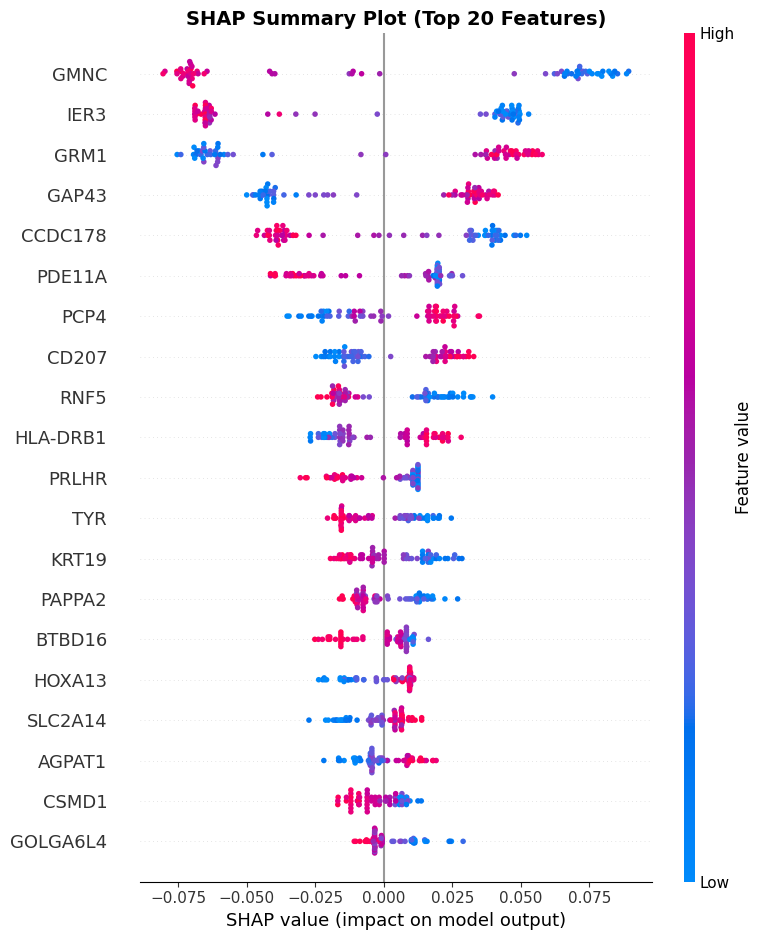

✅ Beeswarm saved


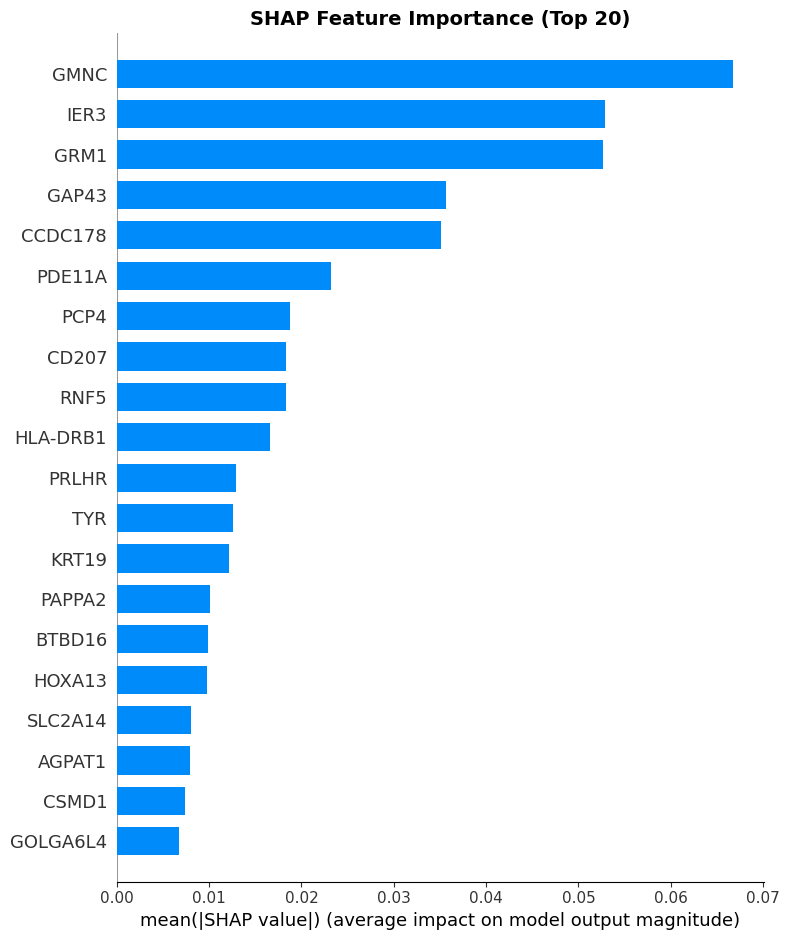

✅ Bar plot saved


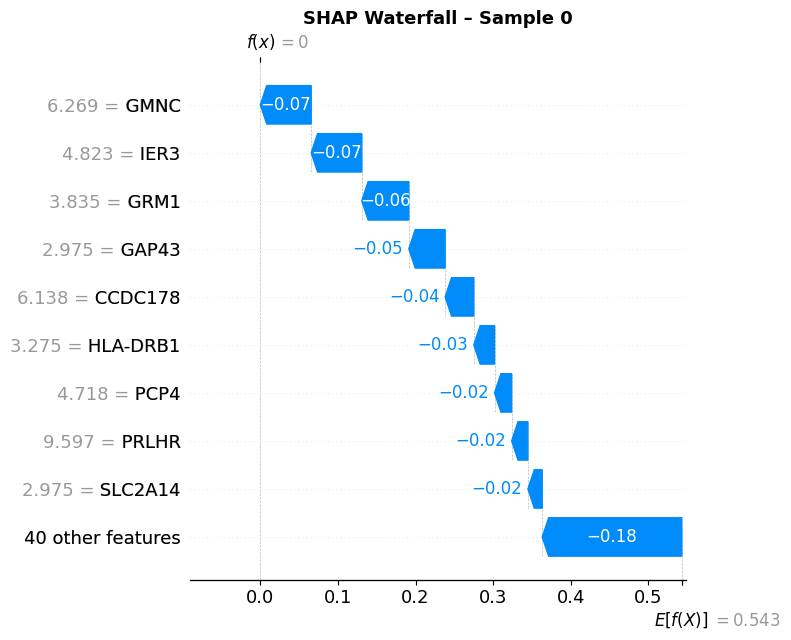

✅ Waterfall saved
✅ Importance CSV saved

Top 10 SHAP Features:
 Feature  Mean_Abs_SHAP
    GMNC       0.066768
    IER3       0.052891
    GRM1       0.052651
   GAP43       0.035695
 CCDC178       0.035141
  PDE11A       0.023212
    PCP4       0.018775
   CD207       0.018363
    RNF5       0.018348
HLA-DRB1       0.016601


In [ ]:
# ==========================
# 9. SHAP VALUES (FIXED)
# ==========================
import shap
import numpy as np
import pandas as pd

print("\nCalculating SHAP values...")
X_array       = X.values.astype(np.float32)
feature_names = list(X.columns)

# Force standard SHAP values — NOT interaction values
explainer = shap.TreeExplainer(best_model)
shap_values_raw = explainer.shap_values(X_array)   # DO NOT pass tree_path_dependent or interactions

# ── Robust extraction ───────────────────────────────────────────────────────
raw = np.array(shap_values_raw) if not isinstance(shap_values_raw, list) else shap_values_raw

if isinstance(raw, list):
    # list of arrays → binary classifier gives [class0, class1]
    arr = np.array(raw[1])          # positive class
    base_val = float(np.array(explainer.expected_value)[1])
    print(f"✅ List format → took index [1], shape: {arr.shape}")
else:
    arr = raw
    ev  = np.array(explainer.expected_value)
    base_val = float(ev[1]) if ev.ndim > 0 and len(ev) > 1 else float(ev.flat[0])
    print(f"Array format, shape: {arr.shape}")

# ── If still 3D, take diagonal (self-interaction = main effect) ─────────────
if arr.ndim == 3:
    print(f"⚠️  3D array {arr.shape} detected → extracting main effects (diagonal)")
    # arr shape is either (n_samples, n_features, n_features) or (n_samples, n_features, 2)
    if arr.shape[2] == arr.shape[1]:
        # True interaction matrix → diagonal gives main effects
        shap_values = np.array([np.diag(arr[i]) for i in range(arr.shape[0])])
    else:
        # (n_samples, n_features, n_classes) → take class 1
        shap_values = arr[:, :, 1]
    print(f"✅ Reduced to 2D: {shap_values.shape}")
elif arr.ndim == 2:
    shap_values = arr
    print(f"✅ Already 2D: {shap_values.shape}")
else:
    raise ValueError(f"Unexpected SHAP array shape: {arr.shape}")

print(f"Final SHAP shape : {shap_values.shape}")   # must be (n_samples, n_features)
print(f"X_array shape    : {X_array.shape}")
print(f"Base value       : {base_val:.4f}")

assert shap_values.shape == X_array.shape, \
    f"Shape mismatch — SHAP: {shap_values.shape}, X: {X_array.shape}"

# ── 9a. Beeswarm Summary ────────────────────────────────────────────────────
plot_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

plt.figure()
shap.summary_plot(
    shap_values, X_array,
    feature_names=feature_names,
    show=False, max_display=20
)
plt.title('SHAP Summary Plot (Top 20 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'shap_summary_{plot_timestamp}.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Beeswarm saved")

# ── 9b. Bar Plot ─────────────────────────────────────────────────────────────
plt.figure()
shap.summary_plot(
    shap_values, X_array,
    feature_names=feature_names,
    plot_type='bar',
    show=False, max_display=20
)
plt.title('SHAP Feature Importance (Top 20)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'shap_bar_{plot_timestamp}.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Bar plot saved")

# ── 9c. Waterfall (sample 0) — guaranteed 1D inputs ─────────────────────────
shap_exp = shap.Explanation(
    values        = shap_values[0],       # 1D (n_features,)
    base_values   = base_val,             # scalar float
    data          = X_array[0],           # 1D (n_features,)
    feature_names = feature_names
)

plt.figure()
shap.waterfall_plot(shap_exp, show=False)
plt.title('SHAP Waterfall – Sample 0', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'shap_waterfall_{plot_timestamp}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Waterfall saved")

# ── 9d. Importance CSV ───────────────────────────────────────────────────────
mean_shap_df = pd.DataFrame({
    'Feature'       : feature_names,
    'Mean_Abs_SHAP' : np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

mean_shap_df.to_csv(f'shap_importance_{plot_timestamp}.csv', index=False)
print(f"✅ Importance CSV saved")
print("\nTop 10 SHAP Features:")
print(mean_shap_df.head(10).to_string(index=False))

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('/content/validation_count_matrix.csv')
data.head()

,Gene,C1,C2,C3,C4,C5,C6,C7,C8,C9,...,D11,D12,D13,D14,D15,D16,D17,D18,D19,D20
0,A1BG,115,85,98,70,146,97,97,29,58,...,88,193,153,125,108,402,249,57,183,132
1,A1BG-AS1,74,41,44,42,70,56,91,35,19,...,37,144,64,63,63,157,101,46,118,107
2,A1CF,0,3,1,8,1,0,6,0,0,...,11,1,1,13,4,0,3,3,5,1
3,A2M,35564,54680,33271,11252,44088,43126,31970,26536,12054,...,24199,30403,17418,18652,55256,37656,28001,11887,32520,25056
4,A2M-AS1,109,112,167,111,135,108,66,92,32,...,164,98,113,107,70,90,49,43,111,47


In [3]:
# ==========================
# 2. LOAD LASSO GENES
# ==========================
lasso_genes = pd.read_csv('/content/LASSO_GENES.txt')
print(f"Loaded {len(lasso_genes)} LASSO genes")

# ==========================
# 3. SELECT ONLY THESE 49 GENES FROM X_val
# ==========================


merged = pd.merge(data, lasso_genes, on="Gene", how="inner")
merged

Loaded 49 LASSO genes


,Gene,C1,C2,C3,C4,C5,C6,C7,C8,C9,...,D11,D12,D13,D14,D15,D16,D17,D18,D19,D20
0,ACSM1,339,482,225,44,62,185,124,131,34,...,109,133,53,89,311,110,104,73,41,217
1,ADORA2B,49,22,20,62,18,37,20,34,3,...,71,31,25,33,37,38,34,3,14,7
2,AGPAT1,94,4,85,31,9,102,1,79,3,...,42,139,51,1,32,183,58,25,7,129
3,BTBD16,48,18,106,40,50,79,3,63,32,...,221,30,124,197,22,19,46,16,1,15
4,CCDC178,7,5,15,24,8,7,22,4,0,...,21,5,11,15,6,9,7,13,2,3
5,CD207,12,112,25,98,222,106,55,98,40,...,14,41,11,7,8,67,21,61,25,87
6,CLRN1,168,16,13,47,20,34,9,31,6,...,21,29,8,300,5,42,19,54,2,7
7,CMA1,1,36,5,6,25,25,7,8,59,...,1,5,3,3,6,3,2,1,2,11
8,CSMD1,27,112,360,187,43,18,111,49,5,...,246,31,333,361,70,2,43,73,56,27
9,DDT,1,2,0,1,20,1,6,0,0,...,0,5,9,1,0,0,6,3,0,1


In [4]:
data = merged.T

In [ ]:
import pandas as pd

In [6]:

import pandas as pd



# Labels from row index
y = data.index.to_series().str[0].map({'C': 0, 'D': 1})
y = y.drop("Gene")
y = y.values.astype(int)

# Feature matrix
data = data.reset_index(drop=True)
data.columns = data.iloc[0]
data = data.drop(data.index[0]).apply(pd.to_numeric)
X = data
y_val = y
X_val = X

import pickle
import joblib
best_model = joblib.load('/content/rf_best_model.pkl')

# Open the file in read-binary mode



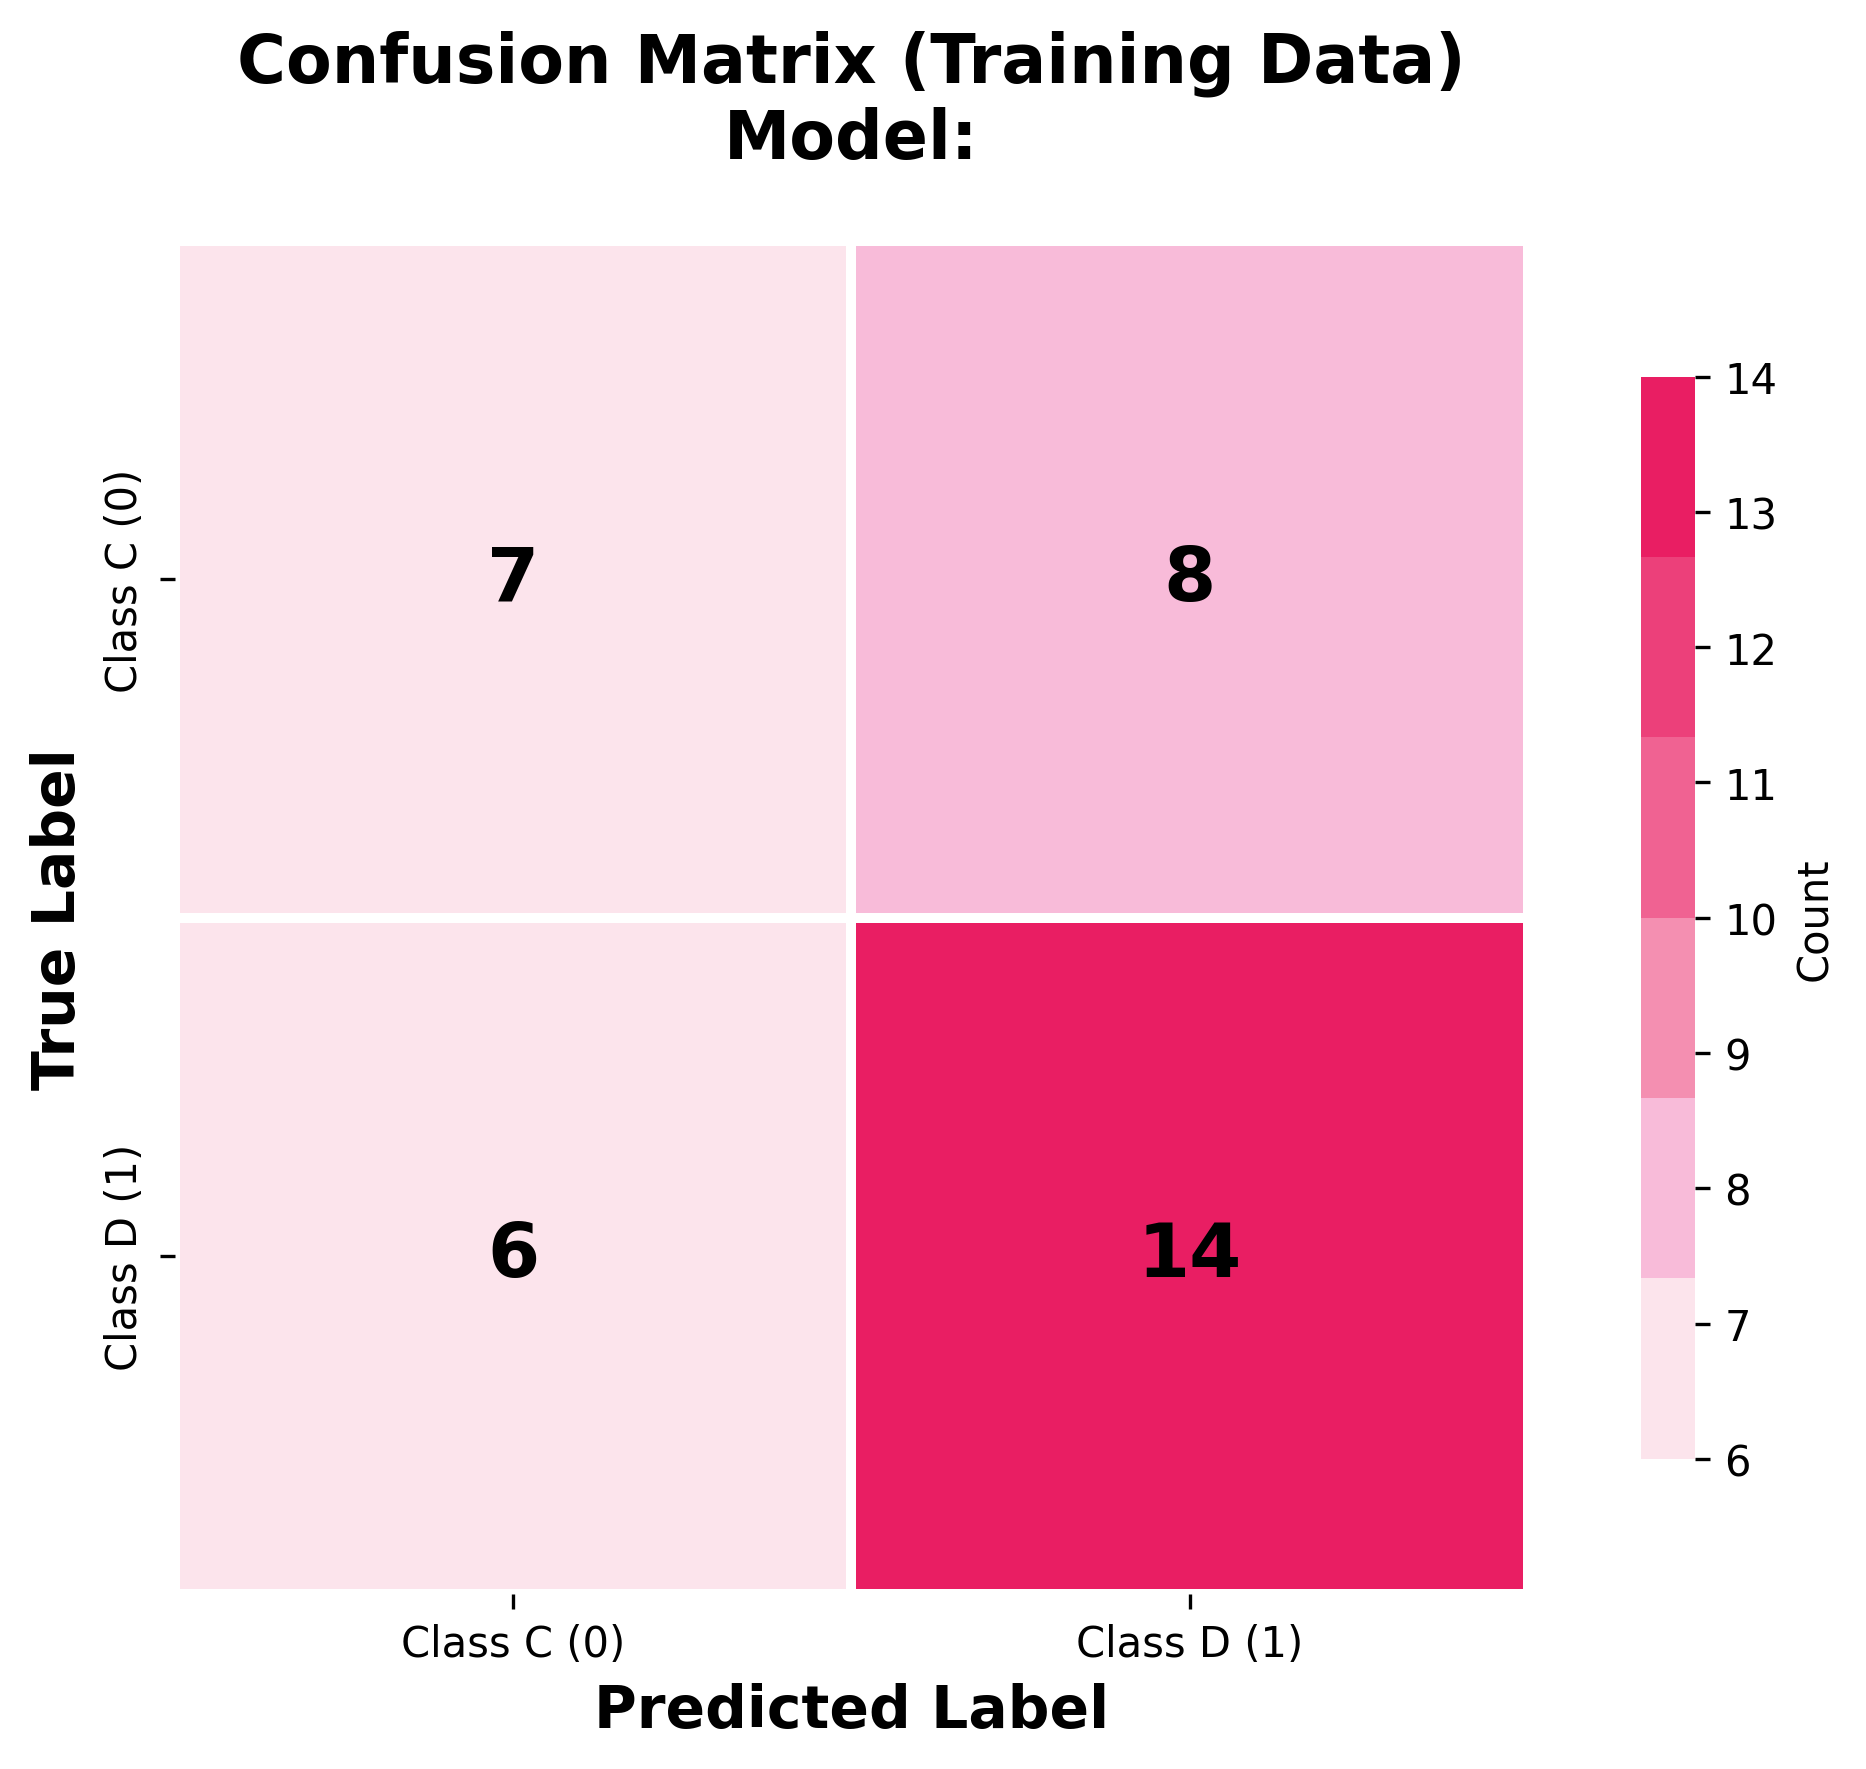


✅ Confusion matrix saved as 'confusion_matrix_.png'

MODEL PERFORMANCE METRICS
Accuracy:  0.6000
Precision: 0.6364
Recall:    0.7000
F1-Score:  0.6667
MCC:       0.1707

CONFUSION MATRIX (Raw Counts)
                    Predicted C    Predicted D
True Class C                 7             8
True Class D                 6            14


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from datetime import datetime

from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, matthews_corrcoef
)
from matplotlib.colors import ListedColormap

# ============================================================
# MAKE PREDICTIONS
# ============================================================
y_pred = best_model.predict(X_val)

# ============================================================
# COMPUTE CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_val, y_pred)

# ============================================================
# PLOT PINK CONFUSION MATRIX
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Sweet pink colormap
pink_colors = ['#fce4ec', '#f8bbd9', '#f48fb1', '#f06292', '#ec407a', '#e91e63']
pink_cmap = ListedColormap(pink_colors)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap=pink_cmap,
    cbar=True,
    cbar_kws={'label': 'Count', 'shrink': 0.8},
    square=True,
    linewidths=2,
    linecolor='white',
    annot_kws={'size': 18, 'weight': 'bold', 'color': 'black'},
    xticklabels=['Class C (0)', 'Class D (1)'],
    yticklabels=['Class C (0)', 'Class D (1)'],
    ax=ax
)

# Title with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=14, fontweight='bold')
plt.title(
    f'Confusion Matrix (Training Data)\nModel:',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.savefig(
    f'confusion_matrix_{timestamp}.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()

print(f"\n✅ Confusion matrix saved as 'confusion_matrix_.png'")

# ============================================================
# PRINT METRICS
# ============================================================
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, zero_division=0)
recall = recall_score(y_val, y_pred, zero_division=0)
f1 = f1_score(y_val, y_pred, zero_division=0)
mcc = matthews_corrcoef(y_val, y_pred)

print("\n" + "="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"MCC:       {mcc:.4f}")

print("\n" + "="*60)
print("CONFUSION MATRIX (Raw Counts)")
print("="*60)
print(f"                    Predicted C    Predicted D")
print(f"True Class C        {cm[0,0]:>10d}    {cm[0,1]:>10d}")
print(f"True Class D        {cm[1,0]:>10d}    {cm[1,1]:>10d}")

In [9]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix
)
from datetime import datetime


# ==========================
# 2. PREPARE VALIDATION DATA (Using all columns - as per your current code)
# ==========================
# Convert to numpy (required for XGBoost)
X_val_array = X_val.values.astype(np.float32)

print(f"Using validation data shape: {X_val_array.shape}")

# ==========================
# 3. PREDICTIONS
# ==========================
y_pred = best_model.predict(X_val_array)
y_pred_proba = best_model.predict_proba(X_val_array)[:, 1]

# ==========================
# 4. CALCULATE ALL METRICS + AUCPRC
# ==========================
metrics = {
    'Accuracy': accuracy_score(y_val, y_pred),
    'ROC-AUC': roc_auc_score(y_val, y_pred_proba),
    'AUCPRC': average_precision_score(y_val, y_pred_proba),   # ← Added AUCPRC
    'Avg Precision': average_precision_score(y_val, y_pred_proba),
    'F1 Score': f1_score(y_val, y_pred),
    'F1 Macro': f1_score(y_val, y_pred, average='macro'),
    'F1 Weighted': f1_score(y_val, y_pred, average='weighted'),
    'Precision': precision_score(y_val, y_pred, zero_division=0),
    'Recall': recall_score(y_val, y_pred, zero_division=0),
    'MCC': matthews_corrcoef(y_val, y_pred),
}

print("\n" + "="*75)
print("📊 VALIDATION SET PERFORMANCE (LASSO 49 Genes)")
print("="*75)

for k, v in metrics.items():
    print(f"{k:20} : {v:.4f}")

print("\n" + "="*75)
print("CLASSIFICATION REPORT")
print("="*75)
print(classification_report(y_val, y_pred, digits=4))

# Save results
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
pd.DataFrame([metrics]).to_csv(f'validation_metrics_{timestamp}.csv', index=False)
print(f"\n✅ Metrics saved as 'validation_metrics_{timestamp}.csv'")

Using validation data shape: (35, 49)

📊 VALIDATION SET PERFORMANCE (LASSO 49 Genes)
Accuracy             : 0.6000
ROC-AUC              : 0.5950
AUCPRC               : 0.6838
Avg Precision        : 0.6838
F1 Score             : 0.6667
F1 Macro             : 0.5833
F1 Weighted          : 0.5952
Precision            : 0.6364
Recall               : 0.7000
MCC                  : 0.1707

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.5385    0.4667    0.5000        15
           1     0.6364    0.7000    0.6667        20

    accuracy                         0.6000        35
   macro avg     0.5874    0.5833    0.5833        35
weighted avg     0.5944    0.6000    0.5952        35


✅ Metrics saved as 'validation_metrics_20260624_0555.csv'


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [10]:
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve


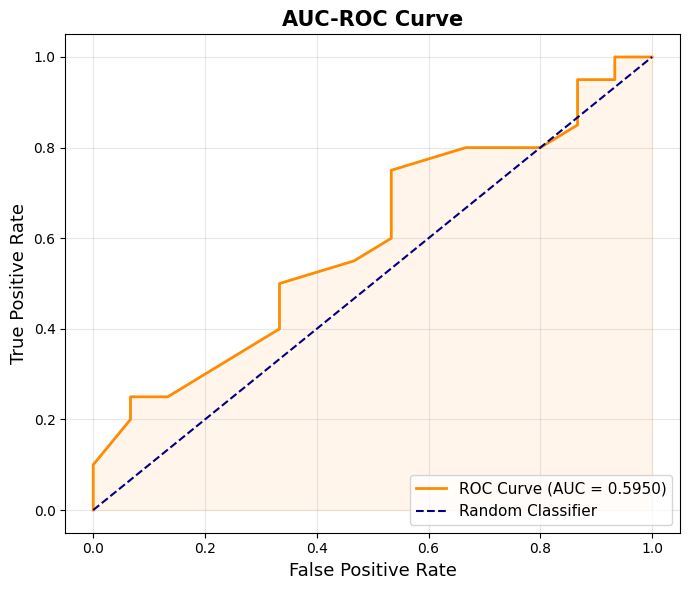

✅ AUC-ROC curve saved as 'aucroc_curve.png'


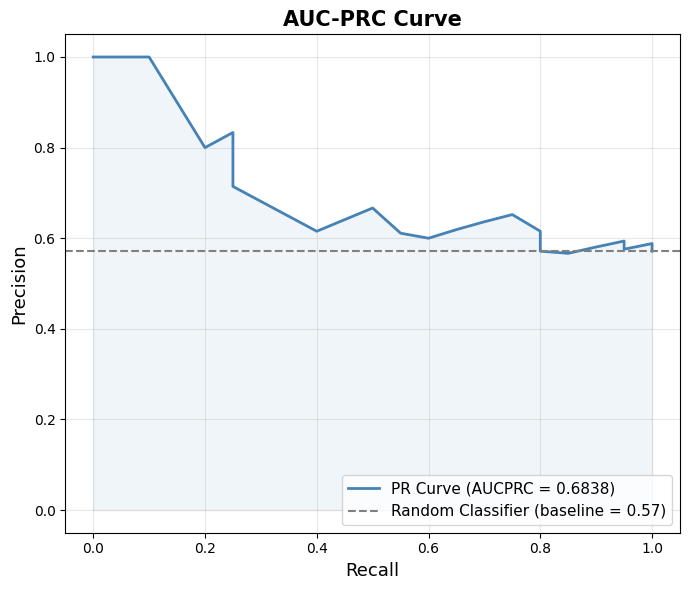

✅ AUC-PRC curve saved as 'aucprc_curve.png'


In [11]:

# ==========================
# 5. AUC-ROC CURVE
# ==========================
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
roc_auc     = metrics['ROC-AUC']

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.08, color='darkorange')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('AUC-ROC Curve', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('aucroc_curve.png', dpi=150)
plt.show()
print("✅ AUC-ROC curve saved as 'aucroc_curve.png'")

# ==========================
# 6. AUC-PRC CURVE
# ==========================
precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_pred_proba)
aucprc   = metrics['AUCPRC']
baseline = np.sum(y_val) / len(y_val)

plt.figure(figsize=(7, 6))
plt.plot(recall_vals, precision_vals, color='steelblue', lw=2,
         label=f'PR Curve (AUCPRC = {aucprc:.4f})')
plt.axhline(y=baseline, color='gray', lw=1.5, linestyle='--',
            label=f'Random Classifier (baseline = {baseline:.2f})')
plt.fill_between(recall_vals, precision_vals, alpha=0.08, color='steelblue')
plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.title('AUC-PRC Curve', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('aucprc_curve.png', dpi=150)
plt.show()
print("✅ AUC-PRC curve saved as 'aucprc_curve.png'")

